In [1]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import median_absolute_error
import pandas as pd
import numpy as np

In [2]:
dataset = pd.read_csv('Earthquakes.csv')


X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

print(X.shape)
print(y.shape)

dataset.head(5)

(1369, 10)
(1369,)


,latitude,longitude,depth,mag,gap,dmin,rms,horizontalError,depthError,magError,meter
0,5.1033,125.3179,44.32,4.3,131,1.970,0.70,5.0,9.3,0.126,18.0
1,-8.8535,117.1527,116.88,4.9,59,2.991,1.06,6.5,7.3,0.091,38.0
2,4.7512,96.2239,10.00,5.3,148,0.862,1.29,6.6,1.8,0.073,18.0
3,-10.1202,118.7274,10.00,4.5,86,3.764,0.95,7.6,1.9,0.084,42.0
4,1.4361,127.0142,120.78,4.5,105,0.748,0.76,8.0,6.6,0.089,37.0


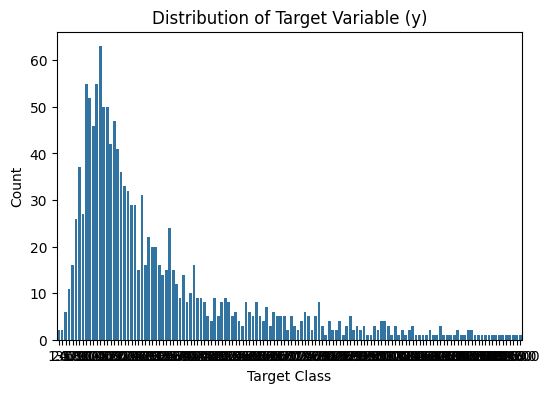

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Distribution of Target Variable (y)')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.show()

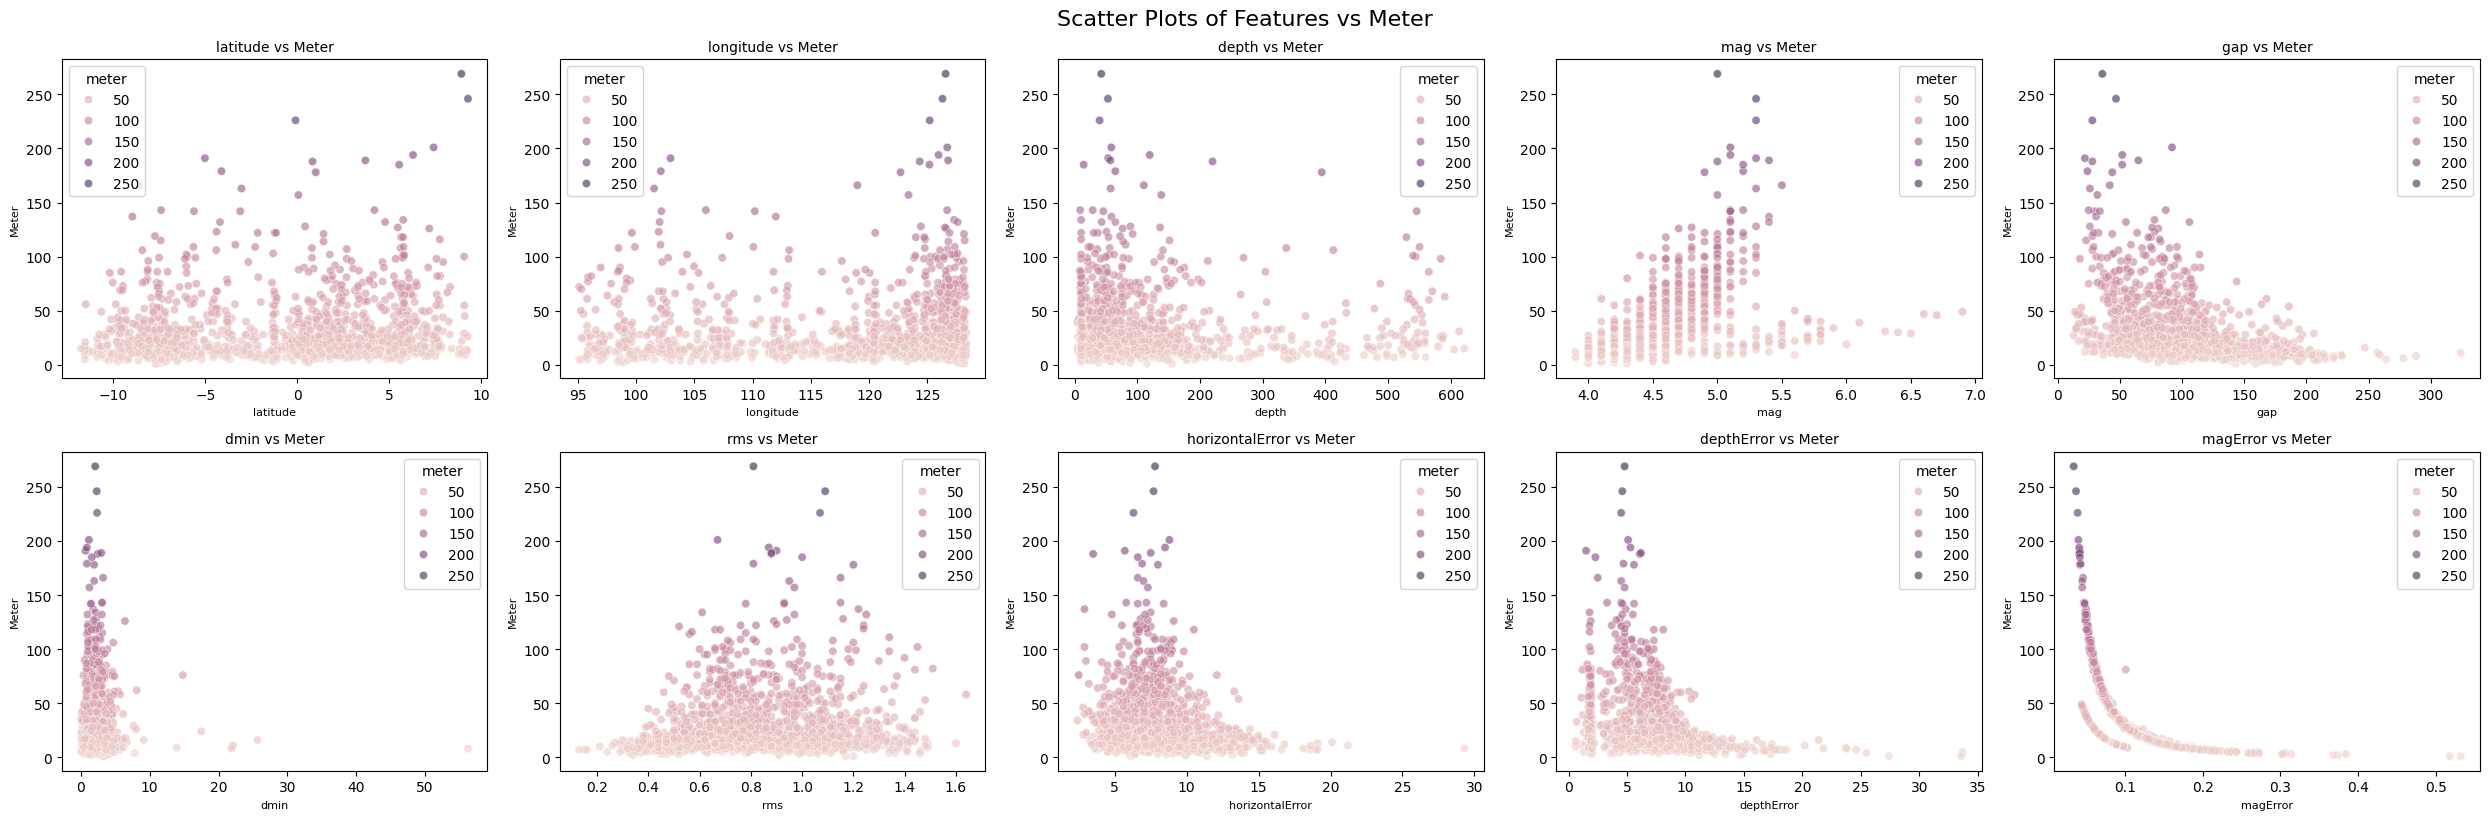

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming dataset, X, and y are already defined from previous cells

# Get feature names from the 'X' DataFrame (which contains features, excluding the target)
feature_names = X.columns.tolist()
n_features = len(feature_names)

# Determine grid size for subplots (e.g., 5 columns)
n_cols = 5
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for i, feature_name in enumerate(feature_names):
    # Use 'y' (the target variable) for the y-axis and hue
    sns.scatterplot(x=dataset[feature_name], y=y, hue=y, ax=axes[i], alpha=0.6)
    axes[i].set_title(f'{feature_name} vs Meter', fontsize=10)
    axes[i].set_xlabel(feature_name, fontsize=8)
    axes[i].set_ylabel('Meter', fontsize=8)
    # The following lines for y-ticks are commented out because 'meter' is a continuous variable, not binary
    # axes[i].set_yticks([0, 1]) # Set y-ticks for binary target
    # axes[i].set_yticklabels(['Benign (0)', 'Malignant (1)']) # Label y-ticks

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Scatter Plots of Features vs Meter', y=1.02, fontsize=16)
plt.show()

In [6]:
print(f"Data types of X:\n{X.dtypes}")
print(f"Are all columns in X numerical? {all(np.issubdtype(dtype, np.number) for dtype in X.dtypes)}")
print(f"Data type of y: {y.dtype}")
print(f"Is y fully numerical? {np.issubdtype(y.dtype, np.number)}")

Data types of X:
latitude           float64
longitude          float64
depth              float64
mag                float64
gap                  int64
dmin               float64
rms                float64
horizontalError    float64
depthError         float64
magError           float64
dtype: object
Are all columns in X numerical? True
Data type of y: float64
Is y fully numerical? True


In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.33,
                                                    random_state=44,
                                                    shuffle=True)

In [8]:
print("Null values in X:", np.isnan(X).sum())
print("Null values in y:", np.isnan(y).sum())

Null values in X: latitude           0
longitude          0
depth              0
mag                0
gap                0
dmin               0
rms                0
horizontalError    0
depthError         0
magError           1
dtype: int64
Null values in y: 1


In [9]:
from sklearn.impute import SimpleImputer

# Impute null values in X_train and X_test with the mean of X_train
imputer_X = SimpleImputer(strategy='mean')
X_train_imputed = pd.DataFrame(imputer_X.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(imputer_X.transform(X_test), columns=X_test.columns, index=X_test.index)

# Impute null values in y_train and y_test with the mean of y_train
imputer_y = SimpleImputer(strategy='mean')
y_train_imputed = pd.Series(imputer_y.fit_transform(y_train.values.reshape(-1, 1)).flatten(), index=y_train.index)
y_test_imputed = pd.Series(imputer_y.transform(y_test.values.reshape(-1, 1)).flatten(), index=y_test.index)

# Update X_train, X_test, y_train, y_test with imputed values
X_train = X_train_imputed
X_test = X_test_imputed
y_train = y_train_imputed
y_test = y_test_imputed

print("Null values in X_train after imputation:", X_train.isnull().sum().sum())
print("Null values in X_test after imputation:", X_test.isnull().sum().sum())
print("Null values in y_train after imputation:", y_train.isnull().sum())
print("Null values in y_test after imputation:", y_test.isnull().sum())

Null values in X_train after imputation: 0
Null values in X_test after imputation: 0
Null values in y_train after imputation: 0
Null values in y_test after imputation: 0


In [10]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the training features (X_train)
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaler to the test features (X_test)
X_test_scaled = scaler.transform(X_test)


In [15]:
SVRModel = SVR(C=1.0, epsilon=0.1, kernel = 'linear')
SVRModel.fit(X_train_scaled, y_train)

SVRModel2 = SVR(C=1.0, epsilon=0.1, kernel = 'poly')
SVRModel2.fit(X_train_scaled, y_train)

SVRModel3 = SVR(C=1.0, epsilon=0.1, kernel = 'rbf')
SVRModel3.fit(X_train_scaled, y_train)

SVR()

In [17]:
print("linear kernel")
print(SVRModel.score(X_train_scaled, y_train))
print(SVRModel.score(X_test_scaled, y_test))

print("poly kernel")
print(SVRModel2.score(X_train_scaled, y_train))
print(SVRModel2.score(X_test_scaled, y_test))

print("rbf kernel")
print(SVRModel3.score(X_train_scaled, y_train))
print(SVRModel3.score(X_test_scaled, y_test))


linear kernel
0.41002767569242515
0.455125049989892
poly kernel
0.23189666781271245
0.22278965862066313
rbf kernel
0.43186716051394636
0.47868978150513963


In [18]:
y_pred = SVRModel.predict(X_test_scaled)

In [19]:
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.2f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Median Absolute Error (MedAE): {median_absolute_error(y_test, y_pred):.2f}")

Mean Squared Error (MSE): 431.74
Mean Absolute Error (MAE): 11.05
Median Absolute Error (MedAE): 3.86
